# Bài 1: Hồi quy tuyến tính
**Học máy ứng dụng — Trường Đại học Văn Lang, Khoa Công nghệ Thông tin**

Notebook này làm lại toàn bộ bài thực hành `Lab01_Hoi_quy_tuyen_tinh.pdf` trên bộ dữ liệu
`gia_nha.csv` (60 căn hộ, 4 cột).

| Phần | Nội dung | Tương ứng trong tài liệu |
|---|---|---|
| A | 7 bước của bài thực hành | Mục 3 → Mục 8 (`b1` … `b7`) |
| B | 6 bài tập nộp | Mục 9 |

**Cách dùng:** chạy lần lượt từ trên xuống (`Shift + Enter`). Mỗi bước đều in ra con số để
đối chiếu với tài liệu — hai bên phải khớp tới từng chữ số.

**Thư viện cần có:** `numpy`, `pandas`, `matplotlib`, `scikit-learn`.
Nếu máy chưa có thì mở cửa sổ lệnh và gõ:

```
pip install numpy pandas matplotlib scikit-learn
```

## 0. Chuẩn bị môi trường

Ô dưới đây nhập bốn thư viện và đọc tệp dữ liệu một lần cho cả notebook.

Về đường dẫn: tài liệu quy ước tệp nằm ở `data/gia_nha.csv`, nhưng nếu notebook đặt
cạnh tệp CSV thì đường dẫn chỉ là `gia_nha.csv`. Ô này tự dò cả hai chỗ nên không cần sửa tay.

In [1]:
# -*- coding: utf-8 -*-
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tìm tệp dữ liệu: ưu tiên bố cục data/ của tài liệu, nếu không có thì lấy tệp cùng thư mục.
DUONG_DAN = Path("data/gia_nha.csv")
if not DUONG_DAN.exists():
    DUONG_DAN = Path("gia_nha.csv")
if not DUONG_DAN.exists():
    raise FileNotFoundError(
        "Khong tim thay gia_nha.csv. Hay dat notebook canh tep CSV, "
        "hoac tao thu muc data/ va bo tep vao do."
    )

print("Doc du lieu tu:", DUONG_DAN.resolve())

# DejaVu Sans (phông mặc định của matplotlib) có đủ dấu tiếng Việt nên hình vẽ hiện đúng chữ.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

Doc du lieu tu: D:\HOC\HMUD\TH\LAB1\gia_nha.csv


---
# Phần A — Bài thực hành

## Bước 1 — Đọc dữ liệu bằng pandas *(Mục 3.3, `b1_doc_du_lieu.py`)*

Năm việc, mỗi việc một lệnh:

- `pd.read_csv` đọc tệp CSV thành một bảng (*DataFrame*), quen đặt tên là `df`.
- `df.shape` trả về cặp số (số dòng, số cột) — cách kiểm tra nhanh nhất xem đọc đúng chưa.
- `df.head()` trả về 5 dòng đầu, để nhìn tận mắt dữ liệu thật.
- `df.describe()` trả về bảng thống kê tóm tắt cho từng cột số.
- `df.isna().sum()` đếm số ô bị thiếu của từng cột — **luôn chạy lệnh này với mọi bộ dữ liệu mới.**

In [2]:
"""Bước 1: đọc tệp dữ liệu và nhìn qua một lượt."""

df = pd.read_csv(DUONG_DAN)

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("Ten cac cot:", list(df.columns))
print()

print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()

print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


**Bốn cột trong tệp** *(Bảng 3 của tài liệu)*

| Tên cột | Ý nghĩa | Đơn vị | Khoảng giá trị |
|---|---|---|---|
| `dien_tich` | Diện tích sàn của căn hộ | m² | 35.5 → 117.5 |
| `so_phong` | Số phòng ngủ | phòng | 1 → 4 |
| `tuoi_nha` | Số năm kể từ khi bàn giao | năm | 0 → 25 |
| `gia` | **Giá bán** của căn hộ | tỷ đồng | 3.00 → 9.74 |

Cột `gia` là thứ ta muốn đoán nên gọi là **biến mục tiêu** (*target*). Ba cột còn lại là căn cứ
để đoán nên gọi là **đặc trưng** (*feature*). Từ Mục 3 tới Mục 7 ta chỉ dùng một đặc trưng
duy nhất là `dien_tich`, tới Mục 8 mới dùng cả ba.

### Nhìn dữ liệu trước khi tính toán *(Mục 3.4 — Hình 1)*

Thói quen bắt buộc của cả môn học: **vẽ dữ liệu ra trước khi tính bất cứ thứ gì.**
Một bảng thống kê chỉ cho vài con số tóm tắt, còn một hình vẽ cho thấy hình dạng của
toàn bộ dữ liệu trong một cái liếc mắt.

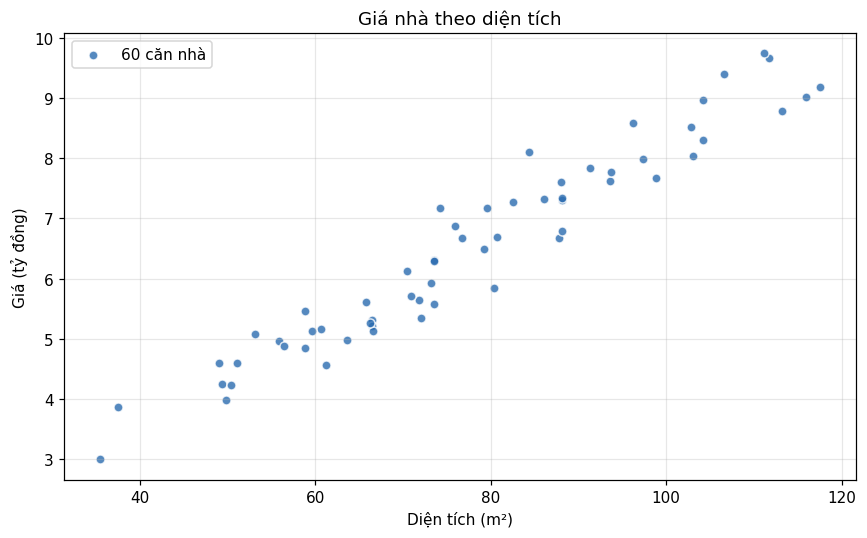

In [3]:
plt.figure()
plt.scatter(df["dien_tich"], df["gia"], s=35, alpha=0.8,
            color="#2b6cb0", edgecolor="white", label="60 căn nhà")
plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Giá nhà theo diện tích")
plt.legend()
plt.tight_layout()
plt.show()

Đọc hình này theo ba câu hỏi:

1. **Các chấm đi theo hướng nào?** Đi lên đều đặn từ trái sang phải — căn càng rộng thì giá
   càng cao, khớp với hiểu biết thông thường về nhà đất.
2. **Các chấm nằm theo hình gì?** Bám khá sát quanh một đường thẳng tưởng tượng, không cong
   lên cũng không cong xuống ở hai đầu → một đường thẳng là lựa chọn hợp lý.
3. **Có chấm nào lạc loài không?** Từ căn nhỏ nhất 35.5 m² tới căn lớn nhất 117.5 m², không
   chấm nào bật hẳn ra xa dải chung → chưa cần bàn tới chuyện loại bỏ điểm ngoại lai (*outlier*).

---
## Bước 2 — Đo sai số của một đường thẳng *(Mục 4, `b2_do_sai_so.py`)*

Mô hình hồi quy tuyến tính một biến gói trọn trong hai con số:

$$\hat{y} = w \cdot x + b$$

- $x$: diện tích căn hộ (m²) — con số ta đưa vào
- $\hat{y}$: giá mô hình đoán ra (tỷ đồng)
- $w$: **hệ số góc** (*slope*) — thêm một mét vuông thì giá tăng thêm bao nhiêu tỷ
- $b$: **hệ số chặn** (*intercept*) — chỗ đường thẳng cắt trục tung

Muốn biết đường nào tốt hơn thì phải chấm điểm được. Thước đo là **MSE** (*mean squared error*),
sai số toàn phương trung bình:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2$$

Ô dưới lấy 5 căn trải đều từ nhỏ nhất tới lớn nhất rồi chấm điểm hai đường thẳng trên đúng 5 căn đó.

In [4]:
"""Bước 2: đo xem một đường thẳng dự đoán sai bao nhiêu.

Chỉ lấy 5 căn cho dễ nhìn. Thử hai đường thẳng khác nhau rồi so sai số
trung bình bình phương của từng đường.
"""

# Lấy 5 căn trải đều từ nhỏ nhất tới lớn nhất, không lấy 5 căn đầu bảng
# vì chúng có diện tích gần bằng nhau nên nhìn không rõ.
nho = df.iloc[[0, 14, 29, 44, 59]]

x_nam_can = nho["dien_tich"].to_numpy()
y_nam_can = nho["gia"].to_numpy()


def mse(w, b):
    """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
    y_du_doan = w * x_nam_can + b
    sai_so = y_nam_can - y_du_doan
    return (sai_so ** 2).mean()


print("Nam can duoc chon:")
for i in range(5):
    print(f"  {x_nam_can[i]:6.1f} m2 -> {y_nam_can[i]:5.2f} ty")
print()

for w_thu, b_thu in [(0.05, 1.5), (0.08, 0.5)]:
    print(f"Duong thang y = {w_thu} * x + {b_thu}")
    for i in range(5):
        du_doan = w_thu * x_nam_can[i] + b_thu
        sai_so = y_nam_can[i] - du_doan
        print(f"  x = {x_nam_can[i]:6.1f}  that = {y_nam_can[i]:5.2f}"
              f"  du doan = {du_doan:5.2f}  sai so = {sai_so:+6.2f}")
    print(f"  MSE = {mse(w_thu, b_thu):.4f}")
    print()

print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon.")

Nam can duoc chon:
    35.5 m2 ->  3.00 ty
    61.3 m2 ->  4.56 ty
    74.2 m2 ->  7.17 ty
    91.3 m2 ->  7.83 ty
   115.9 m2 ->  9.01 ty

Duong thang y = 0.05 * x + 1.5
  x =   35.5  that =  3.00  du doan =  3.28  sai so =  -0.28
  x =   61.3  that =  4.56  du doan =  4.56  sai so =  -0.00
  x =   74.2  that =  7.17  du doan =  5.21  sai so =  +1.96
  x =   91.3  that =  7.83  du doan =  6.07  sai so =  +1.76
  x =  115.9  that =  9.01  du doan =  7.30  sai so =  +1.71
  MSE = 1.9947

Duong thang y = 0.08 * x + 0.5
  x =   35.5  that =  3.00  du doan =  3.34  sai so =  -0.34
  x =   61.3  that =  4.56  du doan =  5.40  sai so =  -0.84
  x =   74.2  that =  7.17  du doan =  6.44  sai so =  +0.73
  x =   91.3  that =  7.83  du doan =  7.80  sai so =  +0.03
  x =  115.9  that =  9.01  du doan =  9.77  sai so =  -0.76
  MSE = 0.3896

Duong nao co MSE nho hon thi duong do khop du lieu tot hon.


Đường thứ nhất đạt MSE = 1.9947, đường thứ hai đạt MSE = 0.3896. **Số nhỏ hơn là số tốt hơn**,
vì MSE đo mức trượt chứ không đo mức giỏi → đường thứ hai thắng, và thắng đậm.

Hãy nhìn kỹ căn 61.3 m²: đường thứ nhất đoán gần như trúng phóc (sai số −0.00) còn đường thứ
hai trượt tới −0.84. Nếu chỉ chấm điểm bằng riêng căn này thì ta sẽ chọn nhầm đường thứ nhất.
Bài học: **một mô hình không được chấm điểm bằng một trường hợp lẻ, mà phải chấm trên toàn bộ dữ liệu.**

### Ba đường thẳng, đường nào đúng *(Hình 2)* và đường cong MSE *(Hình 4)*

Hai hình dưới đây chấm điểm trên **cả 60 căn**. Hình bên trái so ba đường thẳng; hình bên phải
giữ nguyên hệ số chặn tốt nhất rồi cho hệ số góc $w$ chạy dần, mỗi giá trị $w$ cho một con số MSE.

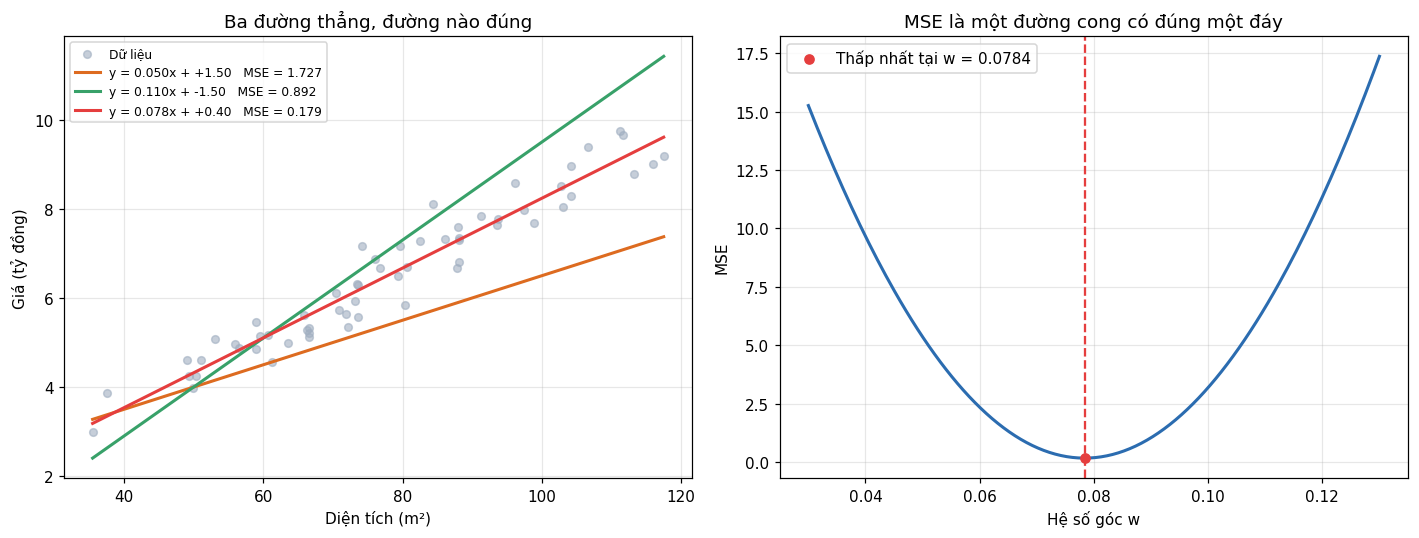

In [5]:
x_tat_ca = df["dien_tich"].to_numpy()
y_tat_ca = df["gia"].to_numpy()


def mse_toan_bo(w, b):
    """MSE tính trên cả 60 căn."""
    return ((y_tat_ca - (w * x_tat_ca + b)) ** 2).mean()


# Nghiệm công thức, sẽ được tính lại từ đầu ở Bước 3.
w_tot = (((x_tat_ca - x_tat_ca.mean()) * (y_tat_ca - y_tat_ca.mean())).sum()
         / ((x_tat_ca - x_tat_ca.mean()) ** 2).sum())
b_tot = y_tat_ca.mean() - w_tot * x_tat_ca.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Hình trái: ba đường thẳng trên cùng đám điểm
ax1.scatter(x_tat_ca, y_tat_ca, s=25, alpha=0.6, color="#a0aec0", label="Dữ liệu")
luoi = np.linspace(x_tat_ca.min(), x_tat_ca.max(), 100)
for w_ve, b_ve, mau in [(0.050, 1.50, "#dd6b20"),
                        (0.110, -1.50, "#38a169"),
                        (w_tot, b_tot, "#e53e3e")]:
    ax1.plot(luoi, w_ve * luoi + b_ve, color=mau, linewidth=2,
             label=f"y = {w_ve:.3f}x + {b_ve:+.2f}   MSE = {mse_toan_bo(w_ve, b_ve):.3f}")
ax1.set_xlabel("Diện tích (m²)")
ax1.set_ylabel("Giá (tỷ đồng)")
ax1.set_title("Ba đường thẳng, đường nào đúng")
ax1.legend(fontsize=8)

# --- Hình phải: MSE là một đường cong có đúng một đáy
day_w = np.linspace(0.03, 0.13, 200)
day_mse = [mse_toan_bo(w_i, b_tot) for w_i in day_w]
ax2.plot(day_w, day_mse, color="#2b6cb0", linewidth=2)
ax2.axvline(w_tot, linestyle="--", color="#e53e3e")
ax2.scatter([w_tot], [mse_toan_bo(w_tot, b_tot)], color="#e53e3e", zorder=5,
            label=f"Thấp nhất tại w = {w_tot:.4f}")
ax2.set_xlabel("Hệ số góc w")
ax2.set_ylabel("MSE")
ax2.set_title("MSE là một đường cong có đúng một đáy")
ax2.legend()

plt.tight_layout()
plt.show()

Đường cong MSE có dạng **lòng chảo, chỉ có đúng một đáy**. Thả hòn bi vào đâu thì nó cũng lăn
về đúng một chỗ. Nhiều bài toán học máy khác có nhiều đáy giả (*local minimum*) nên máy dễ
mắc kẹt; hồi quy tuyến tính không bị chuyện đó — nhờ vậy Bước 3 giải được bằng một công thức
và Bước 6 dò được bằng một vòng lặp đơn giản.

> **Bài toán thật sự cần giải:** trong vô số cặp $w$ và $b$ có thể chọn, hãy tìm cặp làm cho
> MSE nhỏ nhất trên bộ dữ liệu đang có.

---
## Bước 3 — Tìm $w$ và $b$ bằng công thức *(Mục 5.1, `b3_cong_thuc.py`)*

Với một biến đầu vào, bài toán nhỏ gọn tới mức giải được bằng giấy bút. Lời giải đó gọi là
**nghiệm đóng** (*closed form*):

$$w = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2},
\qquad b = \bar{y} - w\bar{x}$$

- **Tử số** cộng dồn tích của hai độ lệch → lớn khi diện tích và giá đi cùng chiều nhau.
- **Mẫu số** đo độ phân tán của riêng diện tích.
- Công thức $b = \bar{y} - w\bar{x}$ nói rằng **đường thẳng tốt nhất luôn đi qua điểm trung bình**
  của đám dữ liệu.

Lưu ý: trong mã **không hề có vòng lặp nào**, vì `numpy` làm việc trên cả mảng một lúc.

In [6]:
"""Bước 3: tìm w và b tốt nhất bằng công thức, không cần thư viện."""

x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu cho đường thẳng một biến
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung binh dien tich : {x_tb:.4f}")
print(f"Trung binh gia       : {y_tb:.4f}")
print(f"Tu so                : {tu_so:.4f}")
print(f"Mau so               : {mau_so:.4f}")
print()
print(f"He so goc       w = {w:.6f}")
print(f"He so chan      b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse_60 = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse_60:.4f}")

# Dự đoán cho một căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich : 77.7317
Trung binh gia       : 6.4933
Tu so                : 1890.2297
Mau so               : 24120.2898

He so goc       w = 0.078367
He so chan      b = 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018

MSE tren toan bo 60 can: 0.1790
Can 80 m2 duoc du doan: 6.671 ty dong


Đọc kết quả bằng lời: $w = 0.078367$ tỷ đồng trên một mét vuông, tức **mỗi mét vuông ở khu vực
này đáng giá khoảng 78 triệu đồng**. Một căn rộng hơn căn khác 10 m² thì theo mô hình sẽ đắt
hơn khoảng 0.78 tỷ.

> ⚠️ **Đừng hiểu sai hệ số chặn.** $b = 0.401752$ **không** có nghĩa là căn hộ rộng 0 m² giá
> 0.4 tỷ. Căn nhỏ nhất trong dữ liệu đã là 35.5 m², nên đoạn đường thẳng kéo về phía 0 chỉ là
> phần mở rộng trên giấy. Hãy hiểu $b$ đơn giản là con số giúp đường thẳng nằm đúng độ cao.

---
## Bước 4 — Để scikit-learn làm *(Mục 5.2, `b4_sklearn.py`)*

Công thức rất đáng hiểu, nhưng trong công việc thật không ai gõ lại nó: dễ sai dấu, chỉ đúng cho
trường hợp một biến, và thư viện đã được hàng triệu người kiểm tra.

**Ba bước chuẩn của mọi mô hình scikit-learn** *(Bảng 4)*:

| Bước | Dòng mã | Máy làm gì |
|---|---|---|
| 1 | `mo_hinh = LinearRegression()` | Tạo ra một mô hình rỗng, chưa học gì cả |
| 2 | `mo_hinh.fit(X, y)` | Học từ dữ liệu, tức tìm `w` và `b` làm sai số nhỏ nhất |
| 3 | `mo_hinh.predict(can_moi)` | Dùng `w`, `b` vừa học để đoán giá cho căn mới |

Khuôn mẫu này dùng chung cho **mọi** mô hình, từ cây quyết định tới máy vectơ tựa — đổi mô hình
chỉ cần thay tên lớp ở bước 1.

> 🔍 **Chỗ sai kinh điển:** `X = df[["dien_tich"]]` có **HAI** cặp ngoặc vuông (bảng hai chiều),
> còn `y = df["gia"]` chỉ **MỘT** cặp (dãy một chiều). Viết nhầm một cặp cho `X` thì gặp lỗi
> `Expected a 2-dimensional container but got pandas.Series instead`.

In [7]:
"""Bước 4: làm lại đúng việc đó bằng scikit-learn, chỉ mất ba dòng."""

from sklearn.linear_model import LinearRegression

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y_cot = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y_cot)

print("He so goc  w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")

He so goc  w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 -> du doan 6.671 ty dong
Can 100 m2 -> du doan 8.238 ty dong


Hai cách cho ra **cùng một kết quả tới từng chữ số**. Đây không phải trùng hợp may mắn: cả hai
đang giải cùng một bài toán, mà bài toán đó chỉ có duy nhất một lời giải vì đường cong sai số
chỉ có đúng một đáy.

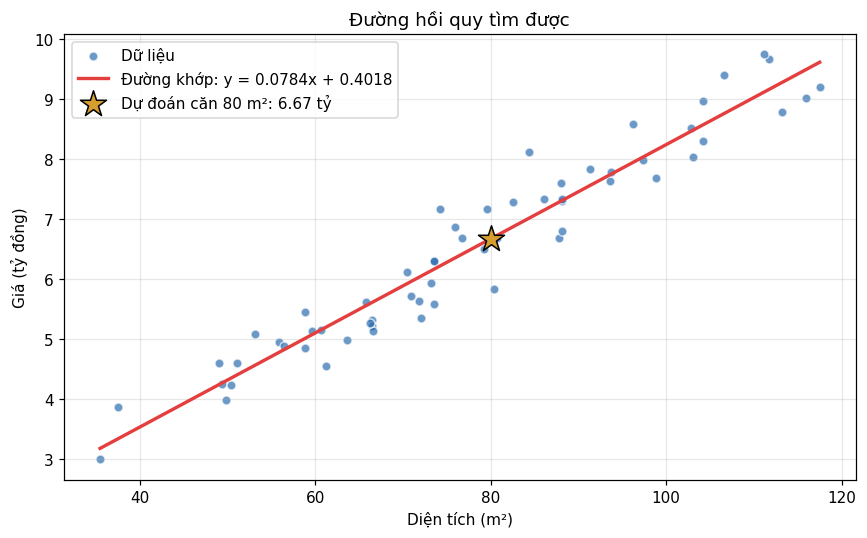

In [8]:
plt.figure()
plt.scatter(x, y, s=35, alpha=0.7, color="#2b6cb0", edgecolor="white", label="Dữ liệu")
luoi = np.linspace(x.min(), x.max(), 100)
plt.plot(luoi, w * luoi + b, color="#e53e3e", linewidth=2.2,
         label=f"Đường khớp: y = {w:.4f}x + {b:.4f}")
plt.scatter([80], [w * 80 + b], marker="*", s=320, color="#d69e2e",
            edgecolor="black", zorder=5, label=f"Dự đoán căn 80 m²: {w*80+b:.2f} tỷ")
plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Đường hồi quy tìm được")
plt.legend()
plt.tight_layout()
plt.show()

---
## Bước 5 — Chia tập và chấm điểm mô hình *(Mục 6, `b5_danh_gia.py`)*

Không được chấm điểm trên chính dữ liệu đã học — giống như cho học sinh thi lại đúng đề đã ôn.
Vì vậy ta **chia dữ liệu**: 80% để học, 20% để kiểm tra.

- `test_size=0.2` → 60 căn chia thành **48 căn học** và **12 căn kiểm tra**.
- `random_state=42` → lần nào chạy cũng bốc đúng 12 căn đó, nhờ vậy kết quả khớp với tài liệu
  và hai mô hình khác nhau được "thi trên cùng một đề". Số 42 không có gì thần thánh, chọn xong
  thì giữ nguyên là được.

**Bốn con số để chấm điểm** ($n$ = số căn kiểm tra, $y_i$ giá thật, $\hat{y}_i$ giá đoán):

| Độ đo | Công thức | Đọc thế nào |
|---|---|---|
| MAE | $\frac{1}{n}\sum\lvert y_i-\hat{y}_i\rvert$ | Trung bình lệch bao nhiêu tỷ — dễ hiểu nhất |
| MSE | $\frac{1}{n}\sum(y_i-\hat{y}_i)^2$ | Đơn vị là tỷ² nên khó hình dung, chỉ dùng để so mô hình |
| RMSE | $\sqrt{\text{MSE}}$ | Kéo sai số về lại đơn vị tỷ đồng |
| $R^2$ | $1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ | Giải thích được bao nhiêu phần biến động; càng gần 1 càng tốt |

In [9]:
"""Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn."""

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X = df[["dien_tich"]]
y_cot = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra.
# random_state cố định để lần nào chia cũng ra đúng một cách chia.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cot, test_size=0.2, random_state=42
)

print("So can de hoc     :", len(X_train))
print("So can de kiem tra:", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)          # chỉ học trên tập học

y_pred = mo_hinh.predict(X_test)       # chấm điểm trên tập kiểm tra

mae = mean_absolute_error(y_test, y_pred)
mse_kt = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse_kt)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f} ty dong")
print(f"MSE  = {mse_kt:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2   = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    print(f"  {dt:6.1f} m2  that = {that:5.2f}  du doan = {du_doan:5.2f}"
          f"  sai so = {that - du_doan:+5.2f}")

So can de hoc     : 48
So can de kiem tra: 12

MAE  = 0.2578 ty dong
MSE  = 0.1392
RMSE = 0.3730 ty dong
R2   = 0.9622

Mot vai can trong tap kiem tra:
    35.5 m2  that =  3.00  du doan =  3.22  sai so = -0.22
    50.4 m2  that =  4.24  du doan =  4.38  sai so = -0.14
    82.5 m2  that =  7.28  du doan =  6.88  sai so = +0.40
    93.6 m2  that =  7.63  du doan =  7.74  sai so = -0.11
    59.6 m2  that =  5.14  du doan =  5.09  sai so = +0.05


Đọc kết quả:

- **MAE = 0.2578 tỷ** → trung bình mỗi căn lệch khoảng **258 triệu đồng**. Trên một căn giá
  trung bình 6.49 tỷ thì mức lệch đó vào khoảng 4% — nghe được với một mô hình chỉ nhìn
  duy nhất diện tích.
- **MSE = 0.1392** thì đừng cố hiểu theo tiền, đơn vị của nó là tỷ đồng bình phương.
- **RMSE = 0.3730 tỷ** mới là con số đọc được, tức khoảng 373 triệu đồng.
- **$R^2$ = 0.9622** → mô hình giải thích được chừng 96% biến động giá của 12 căn kiểm tra.

> **Quy luật luôn đúng: RMSE ≥ MAE.** Phép bình phương thổi phồng các sai số lớn trước khi lấy
> trung bình. Ở đây chênh nhau 0.1152 tỷ — tín hiệu cho biết trong 12 căn có vài căn trượt nặng
> hơn hẳn phần còn lại, chứ sai số không rải đều.

Mô hình ở bước này chỉ học từ 48 căn nên hệ số của nó là $w = 0.077837$, $b = 0.454717$, hơi khác
cặp số của Bước 3 vốn học từ cả 60 căn. Cả hai đều đúng, chúng chỉ đến từ hai lượng dữ liệu khác nhau.

He so hoc tu 48 can: w = 0.077837, b = 0.454717
He so hoc tu 60 can: w = 0.078367, b = 0.401752



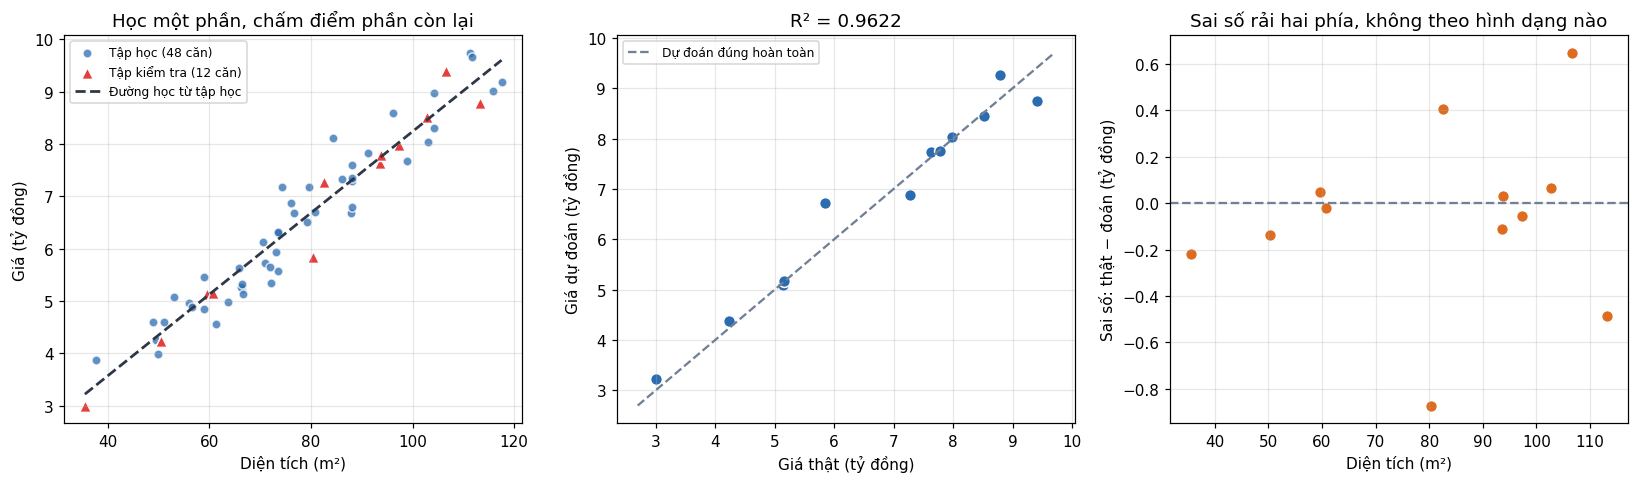

In [10]:
print(f"He so hoc tu 48 can: w = {float(mo_hinh.coef_[0]):.6f}, b = {float(mo_hinh.intercept_):.6f}")
print(f"He so hoc tu 60 can: w = {w:.6f}, b = {b:.6f}")
print()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Cách chia dữ liệu
ax1.scatter(X_train["dien_tich"], y_train, s=35, alpha=0.75, color="#2b6cb0",
            edgecolor="white", label=f"Tập học ({len(X_train)} căn)")
ax1.scatter(X_test["dien_tich"], y_test, s=60, marker="^", color="#e53e3e",
            edgecolor="white", label=f"Tập kiểm tra ({len(X_test)} căn)")
luoi = np.linspace(x.min(), x.max(), 100)
ax1.plot(luoi, float(mo_hinh.coef_[0]) * luoi + float(mo_hinh.intercept_),
         "--", color="#2d3748", linewidth=1.8, label="Đường học từ tập học")
ax1.set_xlabel("Diện tích (m²)")
ax1.set_ylabel("Giá (tỷ đồng)")
ax1.set_title("Học một phần, chấm điểm phần còn lại")
ax1.legend(fontsize=8)

# --- Giá thật so với giá dự đoán
ax2.scatter(y_test, y_pred, s=60, color="#2b6cb0", edgecolor="white")
canh = [min(y_test.min(), y_pred.min()) - 0.3, max(y_test.max(), y_pred.max()) + 0.3]
ax2.plot(canh, canh, "--", color="#718096", label="Dự đoán đúng hoàn toàn")
ax2.set_xlabel("Giá thật (tỷ đồng)")
ax2.set_ylabel("Giá dự đoán (tỷ đồng)")
ax2.set_title(f"R² = {r2:.4f}")
ax2.legend(fontsize=8)

# --- Sai số của từng căn
sai_so_kt = y_test.to_numpy() - y_pred
ax3.scatter(X_test["dien_tich"], sai_so_kt, s=60, color="#dd6b20", edgecolor="white")
ax3.axhline(0, color="#718096", linestyle="--")
ax3.set_xlabel("Diện tích (m²)")
ax3.set_ylabel("Sai số: thật − đoán (tỷ đồng)")
ax3.set_title("Sai số rải hai phía, không theo hình dạng nào")

plt.tight_layout()
plt.show()

---
## Bước 6 — Máy tự dò lời giải bằng gradient descent *(Mục 7, `b6_gradient_descent.py`)*

Hồi quy tuyến tính đã có công thức đóng, nhưng hầu hết mô hình khác thì không. Cách chung cho
mọi trường hợp là **dò dần**: đứng ở một chỗ, nhìn xem hướng nào dốc xuống, rồi bước một bước
theo hướng đó — ý tưởng "người mù xuống núi".

**Quy tắc cập nhật:**

$$w \leftarrow w - \eta\, g_w, \qquad b \leftarrow b - \eta\, g_b$$

với $\eta$ (đọc là *êta*) là **tốc độ học** và $g_w, g_b$ là độ dốc của MSE. Dấu trừ là chỗ
quan trọng nhất: độ dốc chỉ về hướng đi lên, mà ta muốn đi xuống nên phải đi ngược lại.

**Một bước chuẩn bị không được bỏ: chuẩn hoá.** Diện tích là những con số hàng chục nên độ dốc
ở vòng đầu lên tới hàng trăm; nhân với tốc độ học 0.1 thì mỗi bước chân dài hàng chục, nhảy vọt
qua đáy và vài chục vòng là máy in ra `inf` hoặc `nan`. Sau khi trừ trung bình rồi chia độ lệch
chuẩn, gần như toàn bộ $x$ nằm gọn trong khoảng −2 tới 2 và thuật toán chạy êm.

Cái giá phải trả là $w$, $b$ tìm được nằm trên thang đã chuẩn hoá, nên **hai dòng cuối phải đổi
ngược về thang mét vuông.**

In [11]:
"""Bước 6: tự đi tìm w và b bằng cách dò từng bước nhỏ."""

x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x_chuan = (x_goc - x_tb) / x_do_lech

w_gd, b_gd = 0.0, 0.0     # bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1          # mỗi vòng lặp đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x_chuan)

print("Vong       w       b       MSE")
for vong in range(1, so_vong + 1):
    y_du_doan = w_gd * x_chuan + b_gd
    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Bước 2 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x_chuan).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w_gd -= toc_do_hoc * grad_w
    b_gd -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        # Tính lại MSE bằng w và b VỪA cập nhật, để ba con số trên cùng một
        # dòng bảng đều thuộc về cùng một thời điểm.
        mse_vong = (((w_gd * x_chuan + b_gd) - y) ** 2).mean()
        print(f"{vong:4d}  {w_gd:7.4f} {b_gd:7.4f}  {mse_vong:8.4f}")

print()
# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w_gd / x_do_lech
b_goc = b_gd - w_gd * x_tb / x_do_lech
print("Sau khi doi ve thang do met vuong:")
print(f"  w = {w_goc:.6f}")
print(f"  b = {b_goc:.6f}")
print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")

Vong       w       b       MSE
   1   0.3143  1.2987   28.7437
   2   0.5657  2.3376   18.4604
   5   1.0564  4.3656    4.9714
  10   1.4025  5.7961    0.6936
  25   1.5653  6.4688    0.1797
  50   1.5712  6.4932    0.1790
 100   1.5713  6.4933    0.1790
 200   1.5713  6.4933    0.1790

Sau khi doi ve thang do met vuong:
  w = 0.078367
  b = 0.401752
So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752


Bảng này kể lại hành trình xuống đồi. Đường thẳng xuất phát nằm ngang đi qua gốc có MSE 44.8113.
Sau **1 vòng** đã rơi xuống 28.7437, **5 vòng** còn 4.9714, **10 vòng** còn 0.6936, **25 vòng**
còn 0.1797, và từ **vòng 50** trở đi đứng yên ở 0.1790 suốt tới vòng 200.

Đó là hình ảnh kinh điển của gradient descent: xa đáy thì sườn dốc nên bước dài và sai số rơi
nhanh; gần đáy thì sườn thoải nên bước tự động ngắn lại.

**Phần quan trọng nhất:** sau khi đổi về thang mét vuông, máy dò ra đúng $w = 0.078367$ và
$b = 0.401752$ — trùng khít với nghiệm công thức tới chữ số thứ sáu. Công thức đi thẳng tới đáy
trong một bước, gradient descent bò tới đáy qua nhiều bước nhỏ, nhưng **cái đáy thì chỉ có một**.

### Tốc độ học — siêu tham số phải tự chọn *(Mục 7.6 — Hình 10, Hình 12)*

Ô dưới gói thuật toán thành một hàm dùng lại được, rồi chạy với ba tốc độ học khác nhau.
Hàm này còn được dùng lại ở **Bài tập 5**.

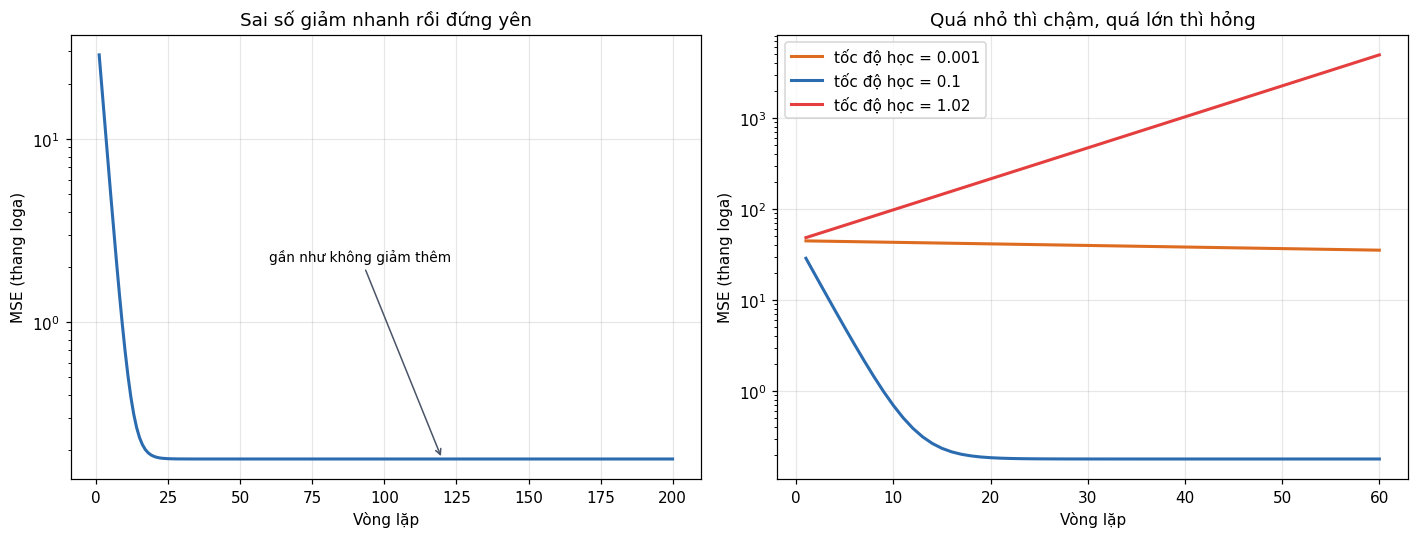

In [12]:
def chay_gradient_descent(toc_do_hoc, so_vong=200, x_dau_vao=None, y_dau_ra=None):
    """Chạy gradient descent trên dữ liệu đã chuẩn hoá.

    Trả về (w, b, lich_su_mse) với lich_su_mse[i] là MSE sau vòng lặp thứ i+1.
    """
    x_c = x_chuan if x_dau_vao is None else x_dau_vao
    y_c = y if y_dau_ra is None else y_dau_ra

    w_i, b_i = 0.0, 0.0
    n_i = len(x_c)
    lich_su = []

    # Với tốc độ học quá lớn, các con số phình to tới mức tràn số. Đó là kết
    # quả đúng của thuật toán chứ không phải máy hỏng, nên ta tắt cảnh báo
    # cho bảng kết quả dễ đọc.
    with np.errstate(over="ignore", invalid="ignore"):
        for _ in range(so_vong):
            chenh_lech = (w_i * x_c + b_i) - y_c
            grad_w = (2 / n_i) * (chenh_lech * x_c).sum()
            grad_b = (2 / n_i) * chenh_lech.sum()
            w_i -= toc_do_hoc * grad_w
            b_i -= toc_do_hoc * grad_b
            lich_su.append((((w_i * x_c + b_i) - y_c) ** 2).mean())

    return w_i, b_i, np.array(lich_su)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Hình 10: sai số giảm nhanh rồi đứng yên
_, _, lich_su_01 = chay_gradient_descent(0.1, 200)
ax1.plot(range(1, 201), lich_su_01, color="#2b6cb0", linewidth=2)
ax1.set_yscale("log")
ax1.set_xlabel("Vòng lặp")
ax1.set_ylabel("MSE (thang loga)")
ax1.set_title("Sai số giảm nhanh rồi đứng yên")
ax1.annotate("gần như không giảm thêm", xy=(120, lich_su_01[119]),
             xytext=(60, lich_su_01[119] * 12),
             arrowprops=dict(arrowstyle="->", color="#4a5568"), fontsize=9)

# --- Hình 12: ba tốc độ học
for lr, mau in [(0.001, "#dd6b20"), (0.1, "#2b6cb0"), (1.02, "#e53e3e")]:
    _, _, ls = chay_gradient_descent(lr, 60)
    ax2.plot(range(1, 61), ls, color=mau, linewidth=2, label=f"tốc độ học = {lr}")
ax2.set_yscale("log")
ax2.set_xlabel("Vòng lặp")
ax2.set_ylabel("MSE (thang loga)")
ax2.set_title("Quá nhỏ thì chậm, quá lớn thì hỏng")
ax2.legend()

plt.tight_layout()
plt.show()

- **0.001** đi xuống rất chậm, sau 60 vòng vẫn chưa tới đáy. Nó không sai, chỉ bước quá ngắn.
- **0.1** xuống nhanh trong vài chục vòng đầu rồi ổn định — dáng điệu ta mong muốn.
- **1.02** đi **lên** chứ không đi xuống: bước quá dài nên từ sườn bên này nhảy vọt qua đáy sang
  sườn bên kia, điểm mới còn cao hơn điểm cũ, và sai số tăng theo cấp số nhân.

> **Dấu hiệu chọn sai tốc độ học:** MSE tăng dần qua các vòng, hoặc màn hình hiện `nan` / `inf`.
> Cách chữa đầu tiên luôn là **giảm tốc độ học xuống mười lần** rồi chạy lại.

---
## Bước 7 — Dùng nhiều hơn một biến *(Mục 8, `b7_nhieu_bien.py`)*

Với ba đặc trưng, mô hình từ một đường thẳng trở thành một mặt phẳng:

$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$$

Trong mã **chỉ đổi đúng một chỗ**: danh sách tên cột đưa vào `X`. Vẫn là `LinearRegression()`,
vẫn `fit`, vẫn `predict`, vẫn `r2_score`. Đó chính là cái lợi của việc scikit-learn cho mọi mô
hình dùng chung một giao diện.

In [13]:
"""Bước 7: dùng thêm số phòng và tuổi nhà, xem mô hình có khá hơn không."""

y_cot = df["gia"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X_i in [("Mot bien", X_mot), ("Ba bien ", X_ba)]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_i, y_cot, test_size=0.2, random_state=42
    )
    mh = LinearRegression()
    mh.fit(X_tr, y_tr)
    r2_i = r2_score(y_te, mh.predict(X_te))
    print(f"{ten}: R2 tren tap kiem tra = {r2_i:.4f}")

print()

# Xem kỹ các hệ số của mô hình ba biến
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X_ba, y_cot, test_size=0.2, random_state=42
)
mo_hinh_ba = LinearRegression()
mo_hinh_ba.fit(X_tr3, y_tr3)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh_ba.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh_ba.intercept_:+.4f}")

Mot bien: R2 tren tap kiem tra = 0.9622
Ba bien : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
  dien_tich    +0.0701
  so_phong     +0.3042
  tuoi_nha     -0.0295
  he so chan   +0.6917


**Đọc ba hệ số bằng lời** *(Bảng 6)*:

| Biến | Hệ số | Đọc bằng lời |
|---|---|---|
| `dien_tich` | +0.0701 | Thêm một mét vuông thì giá tăng khoảng 70 triệu đồng |
| `so_phong` | +0.3042 | Thêm một phòng ngủ thì giá tăng khoảng 304 triệu đồng |
| `tuoi_nha` | −0.0295 | Nhà cũ thêm một năm thì giá giảm khoảng 30 triệu đồng |

Mỗi dòng đều ngầm kèm điều kiện **"hai biến còn lại giữ nguyên"**.

$R^2$ tăng từ 0.9622 lên 0.9761 — có thật, nhưng không lớn: phần biến động chưa giải thích được
chỉ giảm từ ~3.8% xuống ~2.4%. Lý do là **diện tích đã gánh gần hết công việc rồi.**

**Chỗ quan trọng nhất:** hệ số diện tích **giảm** từ 0.0778 (mô hình một biến, cùng 48 căn)
xuống 0.0701. Vì căn rộng thường có nhiều phòng ngủ hơn — ở mô hình một biến, hệ số diện tích
gánh luôn cả phần đóng góp của số phòng; khi đưa `so_phong` vào, cột này nhận lại phần công của
mình nên hệ số diện tích trả bớt.

> ⚠️ **Không được đọc hệ số như quan hệ nhân quả.** Hệ số chỉ mô tả quan hệ thống kê trong đúng
> bộ dữ liệu này. Nó **không** nói rằng đập tường thêm một phòng ngủ là căn hộ có giá thêm 304 triệu.

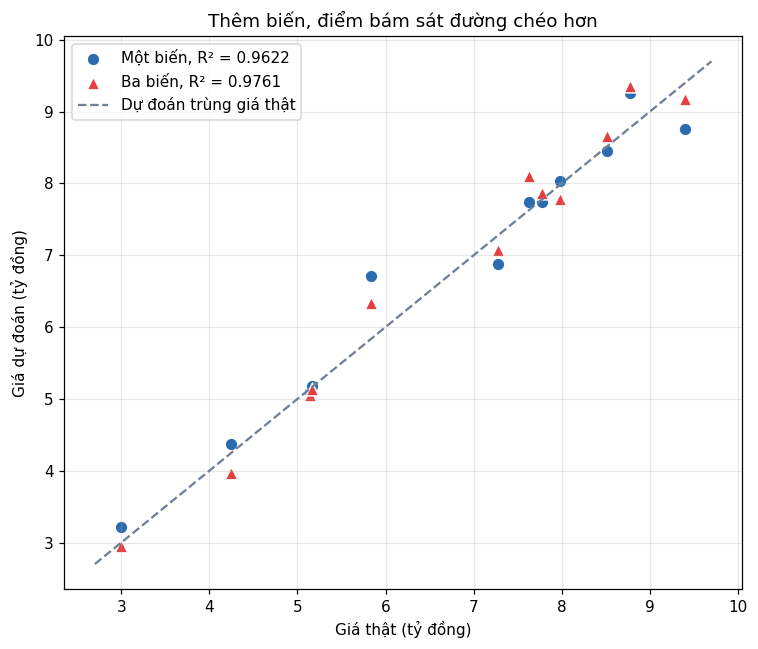

In [14]:
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_mot, y_cot, test_size=0.2, random_state=42
)
mo_hinh_mot = LinearRegression().fit(X_tr1, y_tr1)
pred_mot = mo_hinh_mot.predict(X_te1)
pred_ba = mo_hinh_ba.predict(X_te3)

plt.figure(figsize=(7, 6))
plt.scatter(y_te3, pred_mot, s=70, color="#2b6cb0", edgecolor="white",
            label=f"Một biến, R² = {r2_score(y_te3, pred_mot):.4f}")
plt.scatter(y_te3, pred_ba, s=70, marker="^", color="#e53e3e", edgecolor="white",
            label=f"Ba biến, R² = {r2_score(y_te3, pred_ba):.4f}")
canh = [y_te3.min() - 0.3, y_te3.max() + 0.3]
plt.plot(canh, canh, "--", color="#718096", label="Dự đoán trùng giá thật")
plt.xlabel("Giá thật (tỷ đồng)")
plt.ylabel("Giá dự đoán (tỷ đồng)")
plt.title("Thêm biến, điểm bám sát đường chéo hơn")
plt.legend()
plt.tight_layout()
plt.show()

### Một giới hạn phải nhớ *(Mục 8.4)*

Mô hình chỉ đáng tin **trong vùng dữ liệu nó đã thấy**, tức từ 35.5 tới 117.5 m². Hỏi nó giá của
một căn 250 m² thì nó vẫn trả về một con số, nhưng con số đó chỉ là phần đường thẳng kéo dài
trên giấy, **không có căn nào để đối chiếu cả**. Bài tập 6 ở phần sau sẽ viết một hàm biết tự
cảnh báo chuyện này.

---
# Phần B — Bài tập *(Mục 9)*

Sáu bài đều dùng đúng bộ dữ liệu `gia_nha.csv` với 60 căn hộ ở trên.

**Tiêu chí chấm** (mỗi tiêu chí một phần tư số điểm):

1. Mã chạy được ngay, không báo lỗi và không cần người chấm sửa đường dẫn.
2. Kết quả in ra đúng và khớp với ảnh chụp màn hình nộp kèm.
3. Có nhận xét bằng lời ở những bài yêu cầu, viết thành câu hoàn chỉnh.
4. Tên biến đặt có nghĩa, ví dụ `nhom_lon` hoặc `gia_du_doan`, tránh đặt tên kiểu `a`, `b1`.

> 📌 **Lưu ý khi nộp bài:** thầy yêu cầu mỗi bài là **một tệp `.py` riêng** trong thư mục
> `baitap01` (`bai1.py` … `bai6.py`), chạy bằng `python baitap01/bai1.py` từ thư mục gốc.
> Notebook này dùng để làm và kiểm tra kết quả; khi nộp thì chép nội dung từng ô mã sang tệp
> `.py` tương ứng, thêm các dòng `import` ở đầu và để đường dẫn là `data/gia_nha.csv`.

## Bài tập 1 — Lọc ra nhóm căn hộ lớn

Đọc bộ dữ liệu rồi in ra hai con số: **số căn có diện tích lớn hơn 100 m²** và **giá trung bình
của riêng nhóm căn đó**.

In [15]:
"""Bai 1: dem so can lon hon 100 m2 va tinh gia trung binh cua nhom do."""

nhom_lon = df[df["dien_tich"] > 100]

so_can_lon = len(nhom_lon)
gia_trung_binh_nhom_lon = nhom_lon["gia"].mean()

print(f"So can co dien tich lon hon 100 m2 : {so_can_lon}")
print(f"Gia trung binh cua nhom do         : {gia_trung_binh_nhom_lon:.4f} ty dong")
print()
print(f"De doi chieu, gia trung binh ca 60 can: {df['gia'].mean():.4f} ty dong")
print()
print("Danh sach cac can trong nhom:")
print(nhom_lon.to_string(index=False))

So can co dien tich lon hon 100 m2 : 10
Gia trung binh cua nhom do         : 8.9620 ty dong

De doi chieu, gia trung binh ca 60 can: 6.4933 ty dong

Danh sach cac can trong nhom:
 dien_tich  so_phong  tuoi_nha  gia
     102.8         3         5 8.52
     103.1         3        22 8.04
     104.2         4         8 8.97
     104.2         3         5 8.30
     106.6         4         7 9.40
     111.7         3        14 9.67
     111.2         4         6 9.74
     113.2         3         6 8.78
     117.5         3        18 9.19
     115.9         4        10 9.01


**Nhận xét:** nhóm căn lớn hơn 100 m² chỉ chiếm một phần nhỏ trong 60 căn, và giá trung bình
của riêng nhóm này cao hơn hẳn giá trung bình của cả bộ dữ liệu. Điều đó đúng với xu hướng đã
nhìn thấy ở biểu đồ phân tán ban đầu: căn càng rộng thì giá càng cao.

## Bài tập 2 — Vẽ biểu đồ phân tán theo số phòng

Trục hoành là `so_phong`, trục tung là `gia`. Phải đặt tên hai trục và tiêu đề cho hình, rồi lưu
thành `bai2.png`.

> 💡 Gọi `plt.savefig("bai2.png", dpi=150)` **trước** `plt.show()`, vì `show` đóng hình lại và
> sau đó lưu ra sẽ được một tệp trắng.

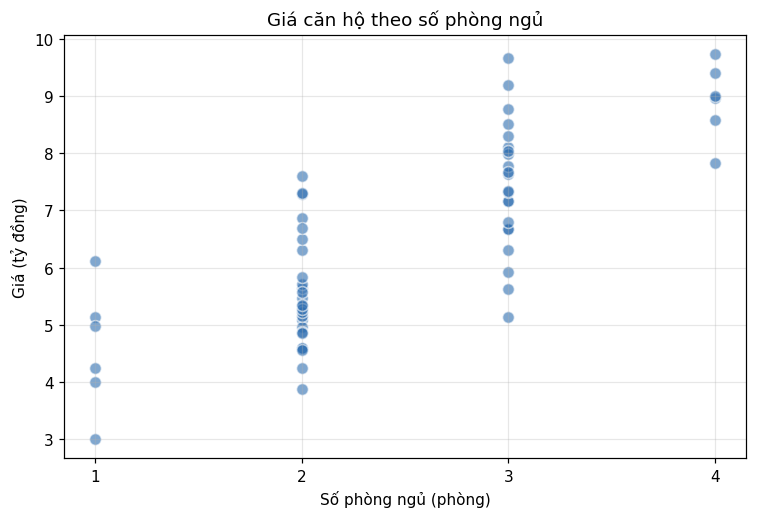

Da luu hinh ra tep bai2.png

Gia trung binh theo tung nhom so phong:
          count   mean   min   max
so_phong                          
1             6  4.578  3.00  6.12
2            26  5.567  3.87  7.60
3            22  7.447  5.13  9.67
4             6  8.923  7.83  9.74

Nhan xet: Gia co xu huong tang dan khi so phong ngu tang, nhung cac cham
xep thanh bon cot doc roi rac chu khong bam quanh mot duong thang.
Trong cung mot so phong, gia van trai rong vai ty dong, nen so phong mo ta
gia kem chi tiet hon nhieu so voi dien tich.


In [16]:
"""Bai 2: ve bieu do phan tan giua so phong va gia, luu ra bai2.png."""

plt.figure()
plt.scatter(df["so_phong"], df["gia"], s=60, alpha=0.6,
            color="#2b6cb0", edgecolor="white")
plt.xlabel("Số phòng ngủ (phòng)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Giá căn hộ theo số phòng ngủ")
plt.xticks(sorted(df["so_phong"].unique()))

plt.savefig("bai2.png", dpi=150, bbox_inches="tight")   # luu TRUOC khi show
plt.show()

print("Da luu hinh ra tep bai2.png")
print()

print("Gia trung binh theo tung nhom so phong:")
gia_theo_phong = df.groupby("so_phong")["gia"].agg(["count", "mean", "min", "max"]).round(3)
print(gia_theo_phong.to_string())
print()

print("Nhan xet: Gia co xu huong tang dan khi so phong ngu tang, nhung cac cham")
print("xep thanh bon cot doc roi rac chu khong bam quanh mot duong thang.")
print("Trong cung mot so phong, gia van trai rong vai ty dong, nen so phong mo ta")
print("gia kem chi tiet hon nhieu so voi dien tich.")

**Nhận xét bằng lời:** giá có xu hướng **tăng dần khi số phòng ngủ tăng**, đúng với cảm nhận
thông thường. Nhưng khác với biểu đồ theo diện tích, các chấm ở đây xếp thành bốn cột dọc rời
rạc chứ không bám quanh một đường thẳng, vì `so_phong` chỉ nhận bốn giá trị nguyên. Trong cùng
một số phòng, giá vẫn trải rộng vài tỷ đồng — nghĩa là số phòng mô tả giá **kém chi tiết hơn
diện tích** khá nhiều.

## Bài tập 3 — Đổi biến đầu vào sang tuổi nhà

Dùng lại đúng công thức bình phương tối thiểu ở Bước 3 nhưng đổi biến đầu vào từ `dien_tich`
sang `tuoi_nha`. In $w$, $b$ với sáu chữ số sau dấu phẩy, rồi giải thích vì sao $w$ mang dấu âm.

In [17]:
"""Bai 3: ap dung cong thuc binh phuong toi thieu voi bien dau vao la tuoi_nha."""

x_tuoi = df["tuoi_nha"].to_numpy()     # CHI DOI DUNG MOT DONG NAY so voi buoc 3
y_gia = df["gia"].to_numpy()

x_tuoi_tb = x_tuoi.mean()
y_gia_tb = y_gia.mean()

tu_so_tuoi = ((x_tuoi - x_tuoi_tb) * (y_gia - y_gia_tb)).sum()
mau_so_tuoi = ((x_tuoi - x_tuoi_tb) ** 2).sum()

w_tuoi = tu_so_tuoi / mau_so_tuoi
b_tuoi = y_gia_tb - w_tuoi * x_tuoi_tb

print(f"Trung binh tuoi nha : {x_tuoi_tb:.4f} nam")
print(f"Trung binh gia      : {y_gia_tb:.4f} ty dong")
print()
print(f"He so goc  w = {w_tuoi:.6f}")
print(f"He so chan b = {b_tuoi:.6f}")
print()
print(f"Mo hinh: gia = {w_tuoi:.6f} * tuoi_nha + {b_tuoi:.6f}")
print("De doi chieu, mo hinh theo dien tich: w = 0.078367, b = 0.401752")
print()

# Do do tin cay cua mo hinh nay
y_du_doan_tuoi = w_tuoi * x_tuoi + b_tuoi
mse_tuoi = ((y_gia - y_du_doan_tuoi) ** 2).mean()
tong_binh_phuong = ((y_gia - y_gia_tb) ** 2).sum()
r2_tuoi = 1 - ((y_gia - y_du_doan_tuoi) ** 2).sum() / tong_binh_phuong
r2_dien_tich = 1 - ((y_gia - (w * x + b)) ** 2).sum() / tong_binh_phuong

print(f"MSE mo hinh theo tuoi nha  : {mse_tuoi:.4f}   R2 = {r2_tuoi:.4f}")
print(f"MSE mo hinh theo dien tich : {((y_gia - (w * x + b)) ** 2).mean():.4f}   R2 = {r2_dien_tich:.4f}")
print()
print(f"He so tuong quan tuoi_nha - gia : {np.corrcoef(x_tuoi, y_gia)[0, 1]:+.4f}")
print(f"He so tuong quan dien_tich - gia: {np.corrcoef(x, y_gia)[0, 1]:+.4f}")

Trung binh tuoi nha : 12.9500 nam
Trung binh gia      : 6.4933 ty dong

He so goc  w = -0.037858
He so chan b = 6.983593

Mo hinh: gia = -0.037858 * tuoi_nha + 6.983593
De doi chieu, mo hinh theo dien tich: w = 0.078367, b = 0.401752

MSE mo hinh theo tuoi nha  : 2.5786   R2 = 0.0262
MSE mo hinh theo dien tich : 0.1790   R2 = 0.9324

He so tuong quan tuoi_nha - gia : -0.1618
He so tuong quan dien_tich - gia: +0.9656


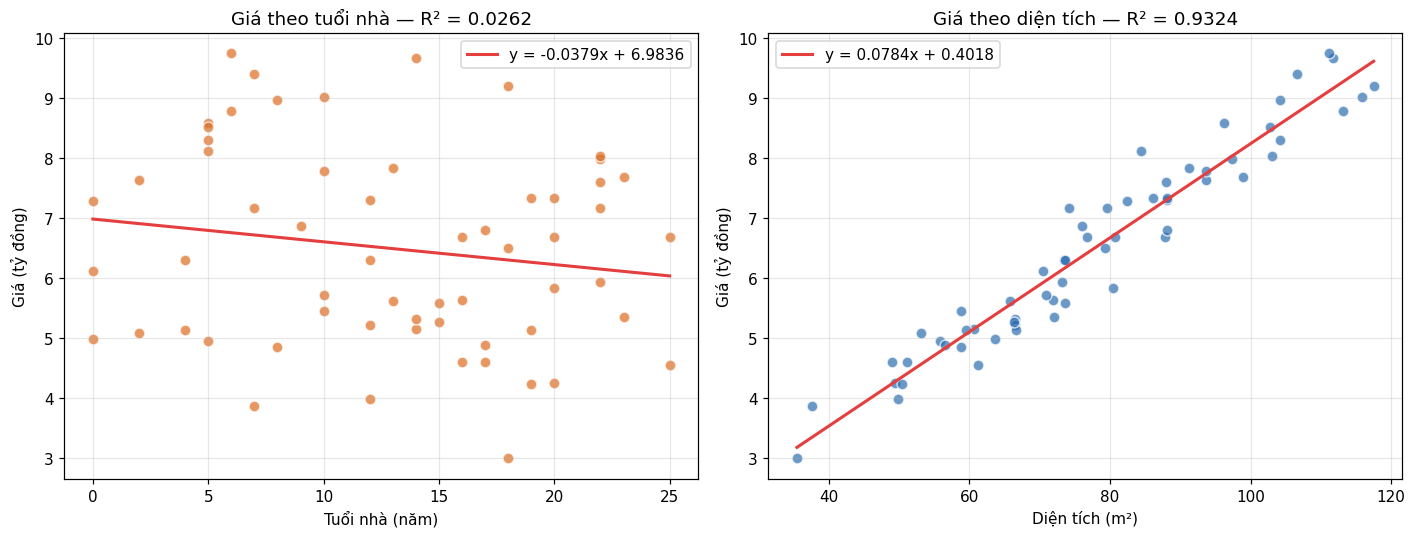

In [18]:
# Cau hoi them: cac diem co that su bam quanh mot duong thang khong?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(x_tuoi, y_gia, s=50, alpha=0.7, color="#dd6b20", edgecolor="white")
luoi_tuoi = np.linspace(x_tuoi.min(), x_tuoi.max(), 50)
ax1.plot(luoi_tuoi, w_tuoi * luoi_tuoi + b_tuoi, color="#e53e3e", linewidth=2,
         label=f"y = {w_tuoi:.4f}x + {b_tuoi:.4f}")
ax1.set_xlabel("Tuổi nhà (năm)")
ax1.set_ylabel("Giá (tỷ đồng)")
ax1.set_title(f"Giá theo tuổi nhà — R² = {r2_tuoi:.4f}")
ax1.legend()

ax2.scatter(x, y_gia, s=50, alpha=0.7, color="#2b6cb0", edgecolor="white")
luoi_dt = np.linspace(x.min(), x.max(), 50)
ax2.plot(luoi_dt, w * luoi_dt + b, color="#e53e3e", linewidth=2,
         label=f"y = {w:.4f}x + {b:.4f}")
ax2.set_xlabel("Diện tích (m²)")
ax2.set_ylabel("Giá (tỷ đồng)")
ax2.set_title(f"Giá theo diện tích — R² = {r2_dien_tich:.4f}")
ax2.legend()

plt.tight_layout()
plt.show()

**Giải thích dấu âm của $w$:** hệ số góc $w$ là mức thay đổi của giá khi tuổi nhà **tăng thêm
một năm**. Nó mang dấu âm vì căn hộ càng cũ thì càng xuống cấp và càng ít được ưa chuộng, nên
giá bán có xu hướng thấp hơn. Cụ thể, mỗi năm tuổi làm giá giảm khoảng vài chục triệu đồng.

**Trả lời câu hỏi thêm:** dấu âm là đúng, **nhưng các điểm không hề bám quanh một đường thẳng.**
Nhìn hình bên trái, đám chấm tản mác gần như đều khắp chứ không tụ lại thành dải. $R^2$ của mô
hình theo tuổi nhà rất thấp so với $R^2$ của mô hình theo diện tích, nghĩa là tuổi nhà **hầu như
không giải thích được** biến động giá.

Kết luận: **một hệ số có dấu đúng chưa đủ để kết luận hai đại lượng có quan hệ chặt.** Dấu chỉ
cho biết *chiều* của xu hướng; muốn biết quan hệ *chặt tới đâu* thì phải nhìn thêm $R^2$, hệ số
tương quan, và quan trọng nhất là **nhìn biểu đồ phân tán**. Con số $w$ này vì vậy không đáng tin
để dự đoán giá nếu chỉ dựa vào riêng tuổi nhà.

## Bài tập 4 — Thêm số phòng vào mô hình

Huấn luyện `LinearRegression` với **hai** cột đầu vào `dien_tich` và `so_phong`, giữ nguyên
`test_size=0.2` và `random_state=42`, rồi so $R^2$ trên tập kiểm tra với mức 0.9622 của mô hình
một biến.

In [19]:
"""Bai 4: mo hinh hai bien dien_tich + so_phong, so R2 voi mo hinh mot bien."""

y_muc_tieu = df["gia"]

danh_sach_mo_hinh = [
    ("Mot bien (dien_tich)",           ["dien_tich"]),
    ("Hai bien (+ so_phong)",          ["dien_tich", "so_phong"]),
    ("Ba bien  (+ tuoi_nha)",          ["dien_tich", "so_phong", "tuoi_nha"]),
]

ket_qua = {}
for ten_mo_hinh, cac_cot in danh_sach_mo_hinh:
    X_i = df[cac_cot]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_i, y_muc_tieu, test_size=0.2, random_state=42
    )
    mo_hinh_i = LinearRegression()
    mo_hinh_i.fit(X_tr, y_tr)
    r2_i = r2_score(y_te, mo_hinh_i.predict(X_te))
    ket_qua[ten_mo_hinh] = (r2_i, mo_hinh_i, cac_cot)
    print(f"{ten_mo_hinh:25s}: R2 tren tap kiem tra = {r2_i:.4f}")

print()

r2_mot_bien = ket_qua["Mot bien (dien_tich)"][0]
r2_hai_bien, mo_hinh_hai_bien, cot_hai_bien = ket_qua["Hai bien (+ so_phong)"]

print("He so cua mo hinh hai bien:")
for ten_cot, he_so in zip(cot_hai_bien, mo_hinh_hai_bien.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh_hai_bien.intercept_:+.4f}")
print()

muc_tang = r2_hai_bien - r2_mot_bien
print(f"R2 di tu {r2_mot_bien:.4f} sang {r2_hai_bien:.4f}, tuc thay doi {muc_tang:+.4f}")
print(f"Phan bien dong chua giai thich duoc: "
      f"{(1 - r2_mot_bien) * 100:.2f}% -> {(1 - r2_hai_bien) * 100:.2f}%")

Mot bien (dien_tich)     : R2 tren tap kiem tra = 0.9622
Hai bien (+ so_phong)    : R2 tren tap kiem tra = 0.9698
Ba bien  (+ tuoi_nha)    : R2 tren tap kiem tra = 0.9761

He so cua mo hinh hai bien:
  dien_tich    +0.0702
  so_phong     +0.2704
  he so chan   +0.3667

R2 di tu 0.9622 sang 0.9698, tuc thay doi +0.0075
Phan bien dong chua giai thich duoc: 3.78% -> 3.02%


**So sánh bằng lời:** thêm cột `so_phong` làm $R^2$ trên tập kiểm tra **tăng từ 0.9622 lên
0.9698**, tức thêm 0.0075. Nói theo cách dễ hình dung hơn, phần biến động giá mà mô hình chưa
giải thích được giảm từ **3.78% xuống 3.02%**. Mức tăng đi đúng hướng ta mong đợi khi cho máy
biết thêm thông tin, nên xét thuần về điểm số thì cột này **có đáng thêm vào**.

Nhưng mức tăng **rất nhỏ**, và lý do đã gặp ở Bước 7: diện tích đã gánh gần hết công việc. Căn
rộng thì thường cũng nhiều phòng, nên hai cột này mang thông tin trùng nhau rất nhiều —
`so_phong` chỉ còn chỗ để tinh chỉnh chứ không đem tới thông tin thật sự mới. So tiếp với mô hình
ba biến (0.9761) thì thấy `tuoi_nha` còn đóng góp nhiều hơn `so_phong`.

Thêm nữa, tập kiểm tra chỉ có **12 căn**, nên một chênh lệch 0.0075 hoàn toàn có thể đảo chiều
nếu đổi `random_state`. Kết luận thận trọng: thêm `so_phong` có ích nhưng ích lợi mỏng; muốn
khẳng định chắc chắn thì cần nhiều dữ liệu kiểm tra hơn hoặc dùng kiểm định chéo
(*cross-validation*).

## Bài tập 5 — Thử hai tốc độ học khác

Giữ nguyên `so_vong = 200`, chỉ sửa đúng dòng gán `toc_do_hoc`. Lần thứ nhất dùng **0.001**,
lần thứ hai dùng **1.02**, rồi ghi lại MSE ở vòng lặp thứ 200. Trong tài liệu, tốc độ học 0.1
cho MSE dừng ở 0.1790.

In [20]:
"""Bai 5: so sanh MSE o vong 200 voi cac toc do hoc khac nhau."""

SO_VONG = 200
cac_toc_do_hoc = [0.001, 0.1, 1.02]


def phan_loai(lich_su):
    """Doc lich su MSE xem thuat toan di xuong, di len, hay chua toi day."""
    mse_cuoi = lich_su[-1]
    if not np.isfinite(mse_cuoi) or mse_cuoi > lich_su[0]:
        return "SAI SO TANG VOT - buoc qua dai"
    if mse_cuoi > 0.2:
        return "chua toi day - buoc qua ngan"
    return "da hoi tu ve day"


print(f"{'Toc do hoc':>11s} | {'MSE o vong 200':>18s} | Nhan xet")
print("-" * 66)

lich_su_cac_lan = {}
for toc_do in cac_toc_do_hoc:
    w_lr, b_lr, lich_su = chay_gradient_descent(toc_do, SO_VONG)
    lich_su_cac_lan[toc_do] = lich_su
    mse_cuoi = lich_su[-1]

    hien_thi = f"{mse_cuoi:.4f}" if np.isfinite(mse_cuoi) and mse_cuoi < 1e6 else f"{mse_cuoi:.4e}"
    print(f"{toc_do:>11} | {hien_thi:>18s} | {phan_loai(lich_su)}")

print()
print("Doi chieu: MSE nho nhat co the dat duoc tren bo du lieu nay la 0.1790")
print("           MSE cua duong thang xuat phat (w = 0, b = 0) la 44.8113")

 Toc do hoc |     MSE o vong 200 | Nhan xet
------------------------------------------------------------------
      0.001 |            20.2175 | chua toi day - buoc qua ngan
        0.1 |             0.1790 | da hoi tu ve day
       1.02 |         2.9039e+08 | SAI SO TANG VOT - buoc qua dai

Doi chieu: MSE nho nhat co the dat duoc tren bo du lieu nay la 0.1790
           MSE cua duong thang xuat phat (w = 0, b = 0) la 44.8113


**Giải thích vì sao hai con số khác nhau:**

- **Tốc độ học 0.001** — bước chân quá ngắn. Thuật toán vẫn đi **đúng hướng** xuống đáy, nhưng
  mỗi vòng chỉ nhích được một đoạn rất nhỏ, nên sau 200 vòng nó vẫn còn nằm trên sườn dốc, chưa
  tới đáy. MSE vì vậy còn lớn hơn 0.1790 khá nhiều. Muốn tới đáy thì phải chạy vài nghìn vòng.

- **Tốc độ học 1.02** — bước chân quá dài. Từ sườn bên này thuật toán **nhảy vọt qua đáy** sang
  sườn bên kia, mà điểm hạ cánh còn cao hơn điểm xuất phát. Vòng sau nó lại nhảy ngược về, xa
  hơn nữa, nên sai số tăng theo **cấp số nhân**. Sau 200 vòng, MSE lên tới cỡ $10^8$ — lớn hơn
  cả MSE của đường thẳng xuất phát (44.8113) hàng triệu lần. Con số kỳ quặc đó là **kết quả đúng**
  của thuật toán chứ không phải máy hỏng; chạy thêm vài trăm vòng nữa là màn hình hiện `inf`.

- **Tốc độ học 0.1** nằm vừa vặn giữa hai thái cực: đủ dài để xuống nhanh, đủ ngắn để không nhảy
  qua đáy.

In [21]:
"""Bai 5, phan lam them: do xem ranh gioi giua chay duoc va hong nam o dau."""

def bi_phan_ky(lich_su):
    """True neu sai so di LEN thay vi di xuong, tuc thuat toan hong."""
    return (not np.isfinite(lich_su[-1])) or lich_su[-1] > lich_su[0]


print("Thu them cac toc do hoc trung gian:")
print(f"{'Toc do hoc':>11s} | {'MSE o vong 200':>18s} | Di xuong hay di len?")
print("-" * 60)
for toc_do in [0.5, 0.9, 0.95, 0.99, 0.999, 1.0, 1.001, 1.01, 1.02]:
    _, _, ls = chay_gradient_descent(toc_do, SO_VONG)
    mse_cuoi = ls[-1]
    hien_thi = f"{mse_cuoi:.4f}" if np.isfinite(mse_cuoi) and mse_cuoi < 1e6 else f"{mse_cuoi:.3e}"
    if not bi_phan_ky(ls):
        chieu = "di xuong"
    elif np.isfinite(mse_cuoi) and np.isclose(mse_cuoi, ls[0]):
        chieu = "DUNG YEN - khong bao gio toi day"
    else:
        chieu = "DI LEN - hong"
    print(f"{toc_do:>11} | {hien_thi:>18s} | {chieu}")

print()

# Do ranh gioi bang phep chia doi khoang.
# Tieu chi "hong" la sai so di len so voi vong dau, khong phai "chua toi day",
# vi voi toc do hoc sat 1.0 thuat toan van di dung huong, chi la di rat cham.
thap, cao = 0.5, 1.5
for _ in range(50):
    giua = (thap + cao) / 2
    _, _, ls = chay_gradient_descent(giua, SO_VONG)
    if bi_phan_ky(ls):
        cao = giua
    else:
        thap = giua

print(f"Ranh gioi do duoc bang phep chia doi khoang: toc do hoc ~ {cao:.6f}")

Thu them cac toc do hoc trung gian:
 Toc do hoc |     MSE o vong 200 | Di xuong hay di len?
------------------------------------------------------------
        0.5 |             0.1790 | di xuong
        0.9 |             0.1790 | di xuong
       0.95 |             0.1790 | di xuong
       0.99 |             0.1928 | di xuong
      0.999 |            20.2175 | di xuong
        1.0 |            44.8113 | DUNG YEN - khong bao gio toi day
      1.001 |            99.4306 | DI LEN - hong
       1.01 |        122947.0009 | DI LEN - hong


       1.02 |          2.904e+08 | DI LEN - hong



Ranh gioi do duoc bang phep chia doi khoang: toc do hoc ~ 1.000000


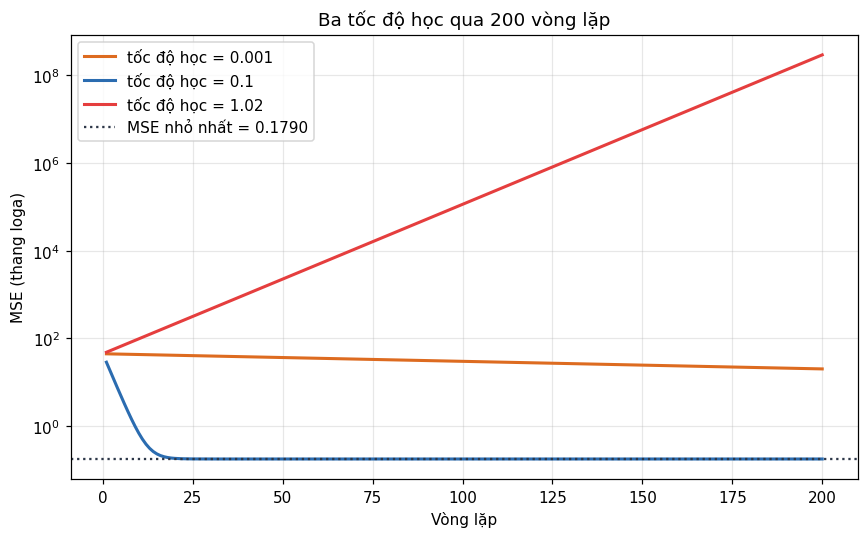

In [22]:
plt.figure()
for toc_do, mau in [(0.001, "#dd6b20"), (0.1, "#2b6cb0"), (1.02, "#e53e3e")]:
    ls = lich_su_cac_lan[toc_do]
    ls_ve = np.where(np.isfinite(ls), ls, np.nan)
    plt.plot(range(1, SO_VONG + 1), ls_ve, color=mau, linewidth=2,
             label=f"tốc độ học = {toc_do}")
plt.axhline(0.1790, linestyle=":", color="#2d3748", label="MSE nhỏ nhất = 0.1790")
plt.yscale("log")
plt.xlabel("Vòng lặp")
plt.ylabel("MSE (thang loga)")
plt.title("Ba tốc độ học qua 200 vòng lặp")
plt.legend()
plt.tight_layout()
plt.show()

**Về ranh giới giữa chạy được và hỏng:** tốc độ học 0.5 và 0.9 **vẫn về đúng 0.1790**, nghĩa là
ranh giới không nằm ở chỗ ta tưởng. Phép chia đôi khoảng ở trên cho thấy ranh giới nằm đúng tại
**η = 1.0**.

Con số này giải thích được. Sau khi chuẩn hoá thì $x$ có trung bình 0 và độ lệch chuẩn 1, nên
quy tắc cập nhật của $w$ rút gọn thành $w \leftarrow w - 2\eta\,(w - w^{*})$, tức khoảng cách tới
đáy bị **nhân với $\lvert 1 - 2\eta \rvert$** sau mỗi vòng. Hệ số đó nhỏ hơn 1 khi và chỉ khi
$0 < \eta < 1$ — đúng bằng ranh giới đo được.

Bảng trên còn cho thấy một chi tiết đáng chú ý: ngay **trước** ranh giới, thuật toán không hỏng
nhưng chậm đi rất nhanh. Với η = 0.999 thì hệ số co lại là 0.998, nên sau 200 vòng khoảng cách
tới đáy mới giảm được chừng một phần ba và MSE vẫn còn 20.2175 — trông y hệt trường hợp η = 0.001
dù nguyên nhân ngược hẳn nhau. Đúng tại η = 1.0 thì hệ số bằng 1, thuật toán nhảy qua nhảy lại
đều đặn và MSE đứng yên ở 44.8113 mãi mãi. Vượt qua 1.0 một chút là sai số bắt đầu tăng theo
cấp số nhân.

## Bài tập 6 — Viết hàm dự đoán có cảnh báo

Viết hàm `du_doan_gia(dien_tich)` dùng lại hai con số $w = 0.078367$ và $b = 0.401752$, in thêm
một dòng cảnh báo nếu diện tích nằm ngoài khoảng 35.5 → 117.5 m².

**Mốc tự kiểm tra:** gọi hàm với 80 m² phải ra **6.671 tỷ đồng**, đúng bằng con số ở Bước 3.

In [23]:
"""Bai 6: ham du doan gia co canh bao khi dien tich nam ngoai vung du lieu."""

# Hai con so lay tu mo hinh mot bien o Buoc 3, khong phai huan luyen lai.
HE_SO_GOC = 0.078367
HE_SO_CHAN = 0.401752

# Vung du lieu ma mo hinh da nhin thay
DIEN_TICH_NHO_NHAT = 35.5
DIEN_TICH_LON_NHAT = 117.5


def du_doan_gia(dien_tich):
    """Du doan gia can ho (ty dong) tu dien tich (m2).

    In canh bao neu dien tich nam ngoai khoang 35.5 - 117.5 m2, vi mo hinh
    chua tung nhin thay vung do nen con so tra ve chi la suy doan keo dai.
    """
    if dien_tich < DIEN_TICH_NHO_NHAT or dien_tich > DIEN_TICH_LON_NHAT:
        print(f"  [CANH BAO] {dien_tich} m2 nam ngoai vung du lieu "
              f"({DIEN_TICH_NHO_NHAT} - {DIEN_TICH_LON_NHAT} m2).")
        print("             Con so duoi day chi la suy doan keo dai, khong dang tin.")

    gia_du_doan = HE_SO_GOC * dien_tich + HE_SO_CHAN
    return gia_du_doan


print(f"Mo hinh: gia = {HE_SO_GOC} * dien_tich + {HE_SO_CHAN}")
print(f"Vung du lieu: {DIEN_TICH_NHO_NHAT} - {DIEN_TICH_LON_NHAT} m2")
print()

for dien_tich_thu in [60, 80, 200]:
    ket_qua_du_doan = du_doan_gia(dien_tich_thu)
    print(f"Can {dien_tich_thu:3d} m2 -> du doan {ket_qua_du_doan:.3f} ty dong")
    print()

print(f"Kiem tra moc: can 80 m2 ra {du_doan_gia(80):.3f} ty dong "
      f"(tai lieu ghi 6.671 ty dong)")

Mo hinh: gia = 0.078367 * dien_tich + 0.401752
Vung du lieu: 35.5 - 117.5 m2

Can  60 m2 -> du doan 5.104 ty dong

Can  80 m2 -> du doan 6.671 ty dong

  [CANH BAO] 200 m2 nam ngoai vung du lieu (35.5 - 117.5 m2).
             Con so duoi day chi la suy doan keo dai, khong dang tin.
Can 200 m2 -> du doan 16.075 ty dong

Kiem tra moc: can 80 m2 ra 6.671 ty dong (tai lieu ghi 6.671 ty dong)


**Vì sao phải cảnh báo:** căn 200 m² nằm xa mọi căn trong dữ liệu — căn lớn nhất mà mô hình từng
thấy mới có 117.5 m². Đường thẳng vẫn kéo dài được tới 200 m² **trên giấy**, nhưng không có một
căn thật nào ở vùng đó để đối chiếu, nên con số trả về chỉ là suy đoán kéo dài (*extrapolation*).

Hai căn 60 m² và 80 m² thì nằm gọn giữa vùng có nhiều dữ liệu, nên dự đoán cho chúng đáng tin
hơn hẳn.

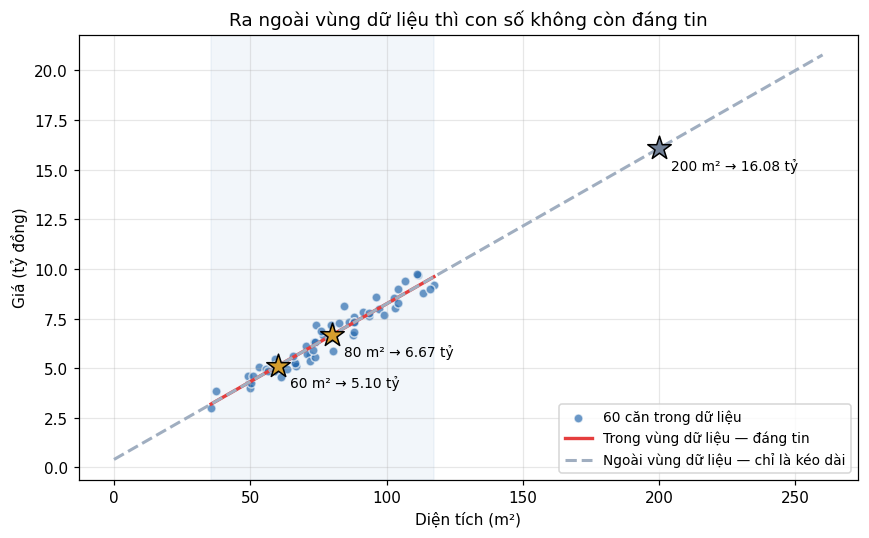

In [24]:
# Ve lai de thay ro vung nao co du lieu va vung nao khong
plt.figure()
plt.scatter(x, y_gia, s=35, alpha=0.7, color="#2b6cb0", edgecolor="white",
            label="60 căn trong dữ liệu")

luoi_rong = np.linspace(0, 260, 300)
trong_vung = (luoi_rong >= DIEN_TICH_NHO_NHAT) & (luoi_rong <= DIEN_TICH_LON_NHAT)
plt.plot(luoi_rong[trong_vung], HE_SO_GOC * luoi_rong[trong_vung] + HE_SO_CHAN,
         color="#e53e3e", linewidth=2.2, label="Trong vùng dữ liệu — đáng tin")
plt.plot(luoi_rong[~trong_vung], HE_SO_GOC * luoi_rong[~trong_vung] + HE_SO_CHAN,
         "--", color="#a0aec0", linewidth=2, label="Ngoài vùng dữ liệu — chỉ là kéo dài")

for dt in [60, 80, 200]:
    gia_dt = HE_SO_GOC * dt + HE_SO_CHAN
    trong = DIEN_TICH_NHO_NHAT <= dt <= DIEN_TICH_LON_NHAT
    plt.scatter([dt], [gia_dt], marker="*", s=260, zorder=5, edgecolor="black",
                color="#d69e2e" if trong else "#718096")
    plt.annotate(f"{dt} m² → {gia_dt:.2f} tỷ", (dt, gia_dt),
                 textcoords="offset points", xytext=(8, -14), fontsize=9)

plt.axvspan(DIEN_TICH_NHO_NHAT, DIEN_TICH_LON_NHAT, color="#2b6cb0", alpha=0.06)
plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Ra ngoài vùng dữ liệu thì con số không còn đáng tin")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Tổng kết — các con số chính của bài *(Phụ lục A.3)*

| Con số | Giá trị | Ở đâu |
|---|---|---|
| Số căn hộ / số cột | 60 / 4 | Bước 1 |
| Diện tích trung bình | 77.7317 m² | Bước 3 |
| Giá trung bình | 6.4933 tỷ | Bước 3 |
| Hệ số góc $w$ (60 căn) | **0.078367** | Bước 3, 4, 6 |
| Hệ số chặn $b$ (60 căn) | **0.401752** | Bước 3, 4, 6 |
| MSE trên cả 60 căn | 0.1790 | Bước 3, 6 |
| Dự đoán căn 80 m² | 6.671 tỷ | Bước 3, Bài tập 6 |
| Chia tập | 48 học / 12 kiểm tra | Bước 5 |
| MAE / RMSE trên tập kiểm tra | 0.2578 / 0.3730 tỷ | Bước 5 |
| $R^2$ một biến / ba biến | 0.9622 / 0.9761 | Bước 5, 7 |

**Bảy việc sinh viên phải tự làm được sau bài này:**

1. Giải thích hồi quy tuyến tính là gì và ý nghĩa của đường thẳng vẽ xuyên qua đám điểm.
2. Đọc tệp CSV bằng `pandas`, xem kích thước bảng và kiểm tra ô trống.
3. Tính sai số của một dự đoán rồi gộp toàn bộ thành một con số MSE.
4. Tìm $w$, $b$ bằng **hai** cách — công thức và scikit-learn — và tự kiểm chứng hai cách trùng nhau.
5. Chia tập học / tập kiểm tra rồi đọc MAE, RMSE, $R^2$.
6. Nhận ra ý tưởng gradient descent: máy tự dò dần tới lời giải khi không có sẵn công thức.
7. Viết mô hình dùng nhiều hơn một biến.